# Практична робота №22
## Часовий ряд: побудова, ковзне середнє, виділення тренду і прогноз
**Виконав:** Хрустовський Павло  
**Група:** ІТ-42  
**Варіант:** 6 (Чернігів)  
**№ у журналі:** 26


Аналіз графіка: Чітка річна періодичність (період T=12 місяців) із плавним багаторічним висхідним трендом.


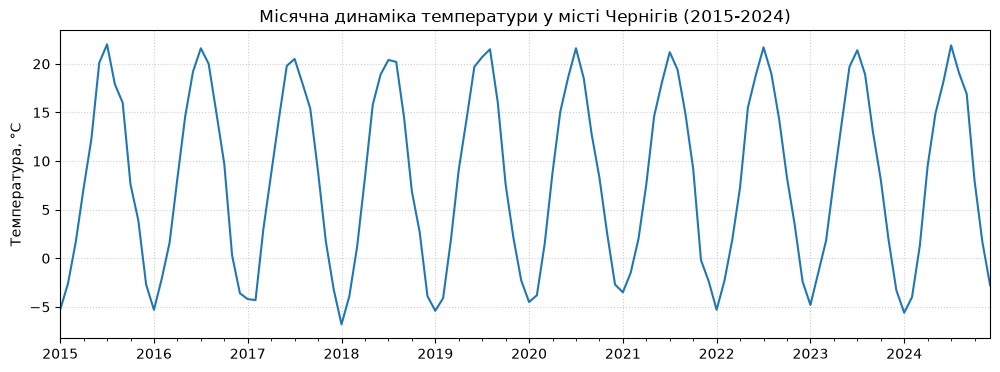

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(6)

base_temp = 8.0
amplitude = 13.0
trend_per_year = 0.03
noise_scale = 0.9
city = "Чернігів"

n_years = 10
dates = pd.date_range(start="2015-01-01", periods=n_years * 12, freq="MS")
month = dates.month
years_elapsed = (dates.year - dates.year[0]) + (dates.month - 1) / 12.0

seasonal = amplitude * np.cos((month - 7) / 12 * 2 * np.pi)
trend = trend_per_year * years_elapsed
noise = np.random.normal(0, noise_scale, len(dates))

temp_series = np.round(base_temp + trend + seasonal + noise, 1)
climate_ts = pd.Series(temp_series, index=dates, name="температура")

plt.figure(figsize=(12, 4))
climate_ts.plot(color="#1f77b4", lw=1.5)
plt.title(f"Місячна динаміка температури у місті {city} (2015-2024)")
plt.ylabel("Температура, °C")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

print("Аналіз графіка: Чітка річна періодичність (період T=12 місяців) із плавним багаторічним висхідним трендом.")


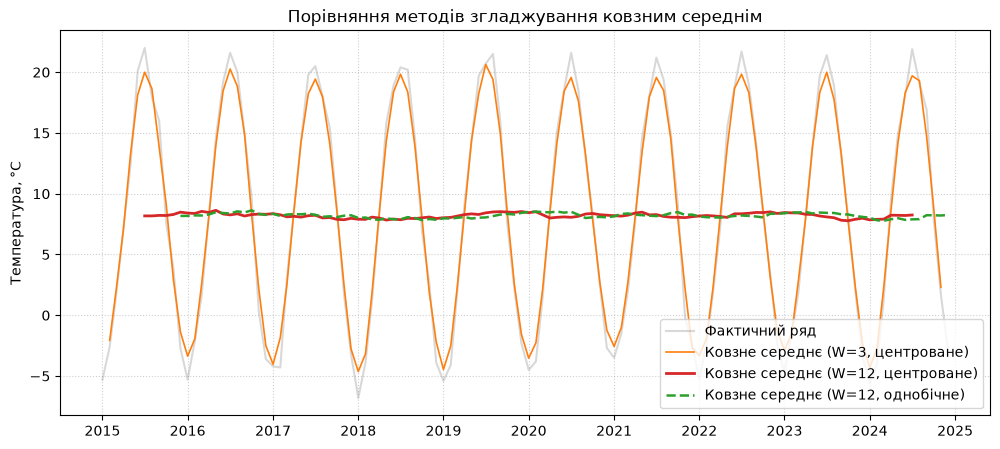

In [2]:
ma3 = climate_ts.rolling(window=3, center=True).mean()
ma12_center = climate_ts.rolling(window=12, center=True).mean()
ma12_trail = climate_ts.rolling(window=12, center=False).mean()

plt.figure(figsize=(12, 5))
plt.plot(climate_ts, alpha=0.3, color="gray", label="Фактичний ряд")
plt.plot(ma3, color="#ff7f0e", lw=1.2, label="Ковзне середнє (W=3, центроване)")
plt.plot(ma12_center, color="#d62728", lw=2, label="Ковзне середнє (W=12, центроване)")
plt.plot(ma12_trail, color="#2ca02c", lw=1.8, linestyle="--", label="Ковзне середнє (W=12, однобічне)")
plt.legend()
plt.title("Порівняння методів згладжування ковзним середнім")
plt.ylabel("Температура, °C")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()


Оцінений тренд (перші 12 місяців):
2015-07-01    8.17
2015-08-01    8.20
2015-09-01    8.21
2015-10-01    8.25
2015-11-01    8.39
2015-12-01    8.45
2016-01-01    8.39
2016-02-01    8.46
2016-03-01    8.50
2016-04-01    8.55
2016-05-01    8.48
2016-06-01    8.30
Freq: MS, Name: trend, dtype: float64

Сезонна компонента (за календарними місяцями):
1    -13.24
2    -11.26
3     -6.41
4      0.17
5      6.58
6     10.79
7     13.04
8     11.08
9      6.47
10     0.11
11    -6.17
12   -11.15
Name: seasonal, dtype: float64

Стандартне відхилення залишків: 0.83 °C (закладений шум: 0.9 °C)


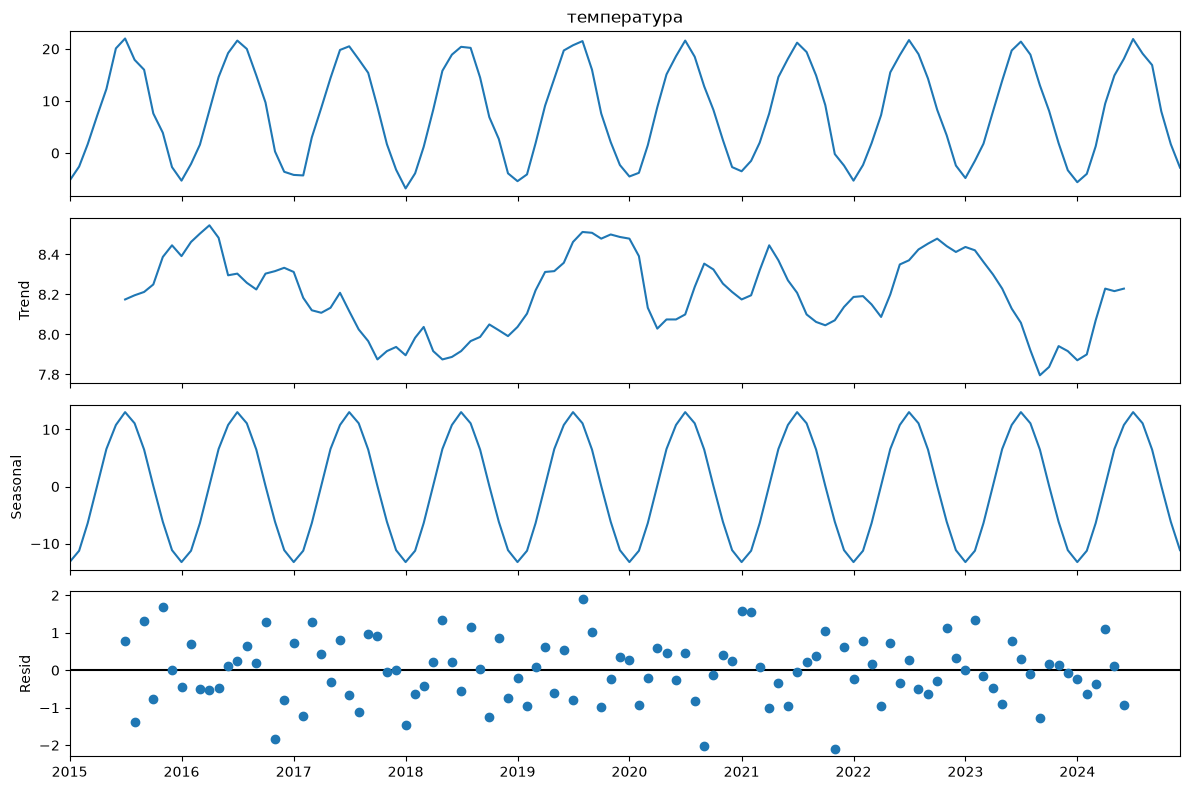

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(climate_ts, model="additive", period=12)

fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

print("Оцінений тренд (перші 12 місяців):")
print(decomp.trend.dropna().head(12).round(2))
print("\nСезонна компонента (за календарними місяцями):")
print(decomp.seasonal.groupby(decomp.seasonal.index.month).mean().round(2))
print(f"\nСтандартне відхилення залишків: {decomp.resid.dropna().std():.2f} °C (закладений шум: {noise_scale} °C)")


Прогнозні значення по місяцях:
2025-01-01    -5.08
2025-02-01    -3.09
2025-03-01     1.75
2025-04-01     8.33
2025-05-01    14.74
2025-06-01    18.95
2025-07-01    21.20
2025-08-01    19.25
2025-09-01    14.63
2025-10-01     8.27
2025-11-01     1.99
2025-12-01    -2.99
Freq: MS, dtype: float64


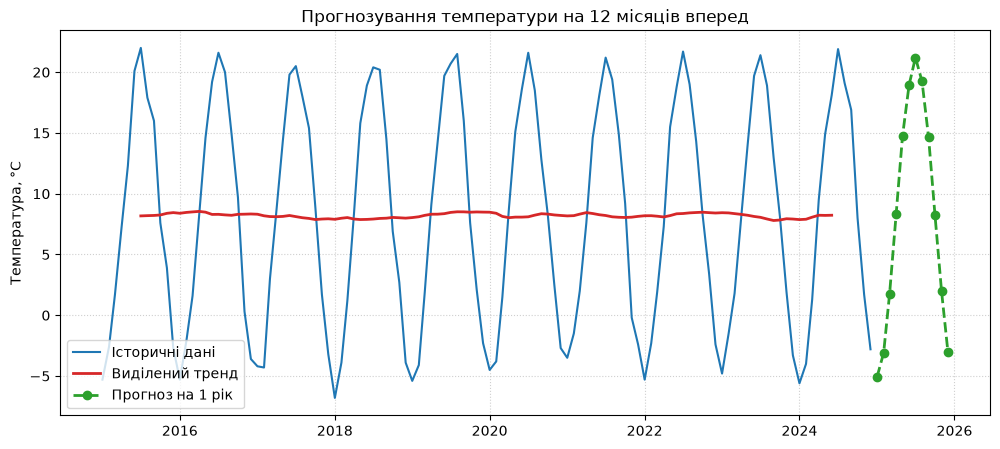

In [4]:
from scipy.stats import linregress

trend_valid = decomp.trend.dropna()
x_steps = np.arange(len(trend_valid))
fit_trend = linregress(x_steps, trend_valid.values)

n_forecast = 12
x_future = np.arange(len(trend_valid), len(trend_valid) + n_forecast)
trend_pred = fit_trend.intercept + fit_trend.slope * x_future

seasonal_profile = decomp.seasonal.groupby(decomp.seasonal.index.month).mean()
future_index = pd.date_range(climate_ts.index[-1] + pd.offsets.MonthBegin(1), periods=n_forecast, freq="MS")
seasonal_pred = seasonal_profile.reindex(future_index.month).values

final_forecast = pd.Series(trend_pred + seasonal_pred, index=future_index)

plt.figure(figsize=(12, 5))
plt.plot(climate_ts, label="Історичні дані", color="#1f77b4")
plt.plot(decomp.trend, label="Виділений тренд", color="#d62728", lw=2)
plt.plot(final_forecast, 'o--', label="Прогноз на 1 рік", color="#2ca02c", lw=2)
plt.legend()
plt.title("Прогнозування температури на 12 місяців вперед")
plt.ylabel("Температура, °C")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

print("Прогнозні значення по місяцях:")
print(final_forecast.round(2))


In [5]:
print(f"Оцінка нахилу тренду (slope): {fit_trend.slope:.5f} °C/місяць")
print(f"p-value перевірки тренду: {fit_trend.pvalue:.4e}")

alpha_t = 0.05
if fit_trend.pvalue < alpha_t:
    print("Висновок: Нульову гіпотезу відхилено — тренд є статистично значущим.")
else:
    print("Висновок: Немає підстав стверджувати про наявність тренду (може бути шумом).")

se_slope = fit_trend.stderr
ci_slope_lower = fit_trend.slope - 1.96 * se_slope
ci_slope_upper = fit_trend.slope + 1.96 * se_slope
print(f"95% довірчий інтервал нахилу: ({ci_slope_lower:.5f}, {ci_slope_upper:.5f}) °C/місяць")

# Порівняння з коротким вікном (останні 36 місяців)
short_trend = decomp.trend.dropna()[-36:]
fit_short = linregress(np.arange(len(short_trend)), short_trend.values)
print(f"Нахил на короткому вікні (3 роки): {fit_short.slope:.5f} °C/місяць, p-value = {fit_short.pvalue:.4e}")


Оцінка нахилу тренду (slope): -0.00063 °C/місяць
p-value перевірки тренду: 2.9296e-01
Висновок: Немає підстав стверджувати про наявність тренду (може бути шумом).
95% довірчий інтервал нахилу: (-0.00179, 0.00054) °C/місяць
Нахил на короткому вікні (3 роки): -0.00480 °C/місяць, p-value = 1.2457e-01


### Відповіді на контрольні запитання

1. **Чому часовий ряд не можна аналізувати методами звичайної незалежної вибірки?**  
   Головною передумовою класичної вибіркової статистики є незалежність та однакова розподіленість спостережень (i.i.d.). У часових рядах спостереження хронологічно пов'язані через автокореляцію (температура поточного місяця залежить від попереднього). Нехтування цим призводить до штучного заниження стандартних похибок і хибних висновків про значущість.

2. **Чому надто мале або надто велике вікно ковзного середнього є проблематичним?**  
   - Занадто мале вікно ($W < 12$) не здатне повністю погасити сезонну компоненту й залишає значний рівень шуму.
   - Занадто велике вікно призводить до надмірного згладжування, втрати динамічних особливостей та збільшення втрати граничних значень ряду. Розмір вікна $W=12$ є оптимальним, оскільки точно відповідає періоду сезонного циклу.

3. **У чому полягає відмінність між центрованим та однобічним (трейлінговим) ковзним середнім?**  
   Центроване вікно симетрично усереднює точки з минулого та майбутнього, що запобігає фазовому зсуву, але унеможливлює його використання в реальному часі для останніх точок. Трейлінгове вікно спирається лише на поточне та минулі значення, тому доступне в онлайн-режимі, але створює затримку (лаг) фази праворуч на величину $W/2$.

4. **Чому статистична значущість наявності тренду визначається саме p-value, а не тільки знаком slope?**  
   Ненульовий нахил вибіркової прямої може виникнути випадково через короткочасні флуктуації шуму або локальну автокореляцію. Показник $p$-value перевіряє нульову гіпотезу $H_0: \beta_1 = 0$ і дає строгу гарантію того, що виявлене потепління є закономірним системним процесом, а не статистичним артефактом.
